In [1]:
#Use this cell only if you are using colab and saving the distributions in your google drive account
from google.colab import drive
# Mount your Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#!pip -q install numpy pandas matplotlib scikit-learn tqdm vector
#!pip install --upgrade gdown
!pip -q install pylhe

import sys
import importlib
import os
import urllib.request
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
import glob
import gc



# Force-download the newest version of the helper file
!wget -q -O helpers.py https://raw.githubusercontent.com/andlessa/UnfoldingBSMttbar/develop/helpers.py

# Import the module and force Python to clear cache and reload it
import helpers as hp
importlib.reload(hp)

# Global Plotting Configuration
plt.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 12, "axes.labelsize": 14, "axes.titlesize": 14,
    "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.linewidth": 1.0, "lines.linewidth": 2.2, "lines.markersize": 4.5,
    "legend.frameon": False, "mathtext.fontset": "cm",
})

# Dictionaries for styling
pair_colors = {"Scalar vs VLF": "#1f77b4", "Scalar vs Zprime": "#2ca02c", "VLF vs Zprime": "#d62728"}
class_colors = {"Scalar": "#1f77b4", "VLF": "#ff7f0e", "Zprime": "#2ca02c"}
pair_latex = {"Scalar vs VLF": r"Scalar vs VLF", "Scalar vs Zprime": r"Scalar vs $Z^\prime$", "VLF vs Zprime": r"VLF vs $Z^\prime$"}
class_latex = {"Scalar": r"Scalar", "VLF": r"VLF", "Zprime": r"$Z^\prime$"}
syst_styles = {0.00: ("black", "-"), 0.02: ("#1f77b4", "--"), 0.05: ("#ff7f0e", "-."), 0.10: ("#d62728", ":")}
eps_styles = {
    0.0: ('-', 'D'),
    0.02: ("-.", "o"),
    0.05: ("--", "s"),
    0.10: (":", "^")
}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.6/919.6 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.7/656.7 kB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.1/315.1 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.2/181.2 kB 14.6 MB/s eta 0:00:00


In [3]:
!pip -q install pylhe
import helpers as hp
importlib.reload(hp)

<module 'helpers' from '/content/helpers.py'>

In [4]:
# ************************************************************
# Grab a coffe, this might take some time! (~15 min)
# ************************************************************

# ============================================================
# Execute Data Extraction
# ============================================================
#If you are going to use colab you can download the FullSamples_LHEs and save it in you google drive. Then the paths should be the same.
#In other case the paths to the FullSamples_LHEs folder should be altered.

# Standard Model (LO)
df_sm = hp.load_lhe_with_corrections(
    './drive/MyDrive/FullSamples_LHEs/SM/*.lhe.gz',
    label='SM',
    is_nlo=False
)

# VLF (NLO)
df_vlf = hp.load_lhe_with_corrections(
    './drive/MyDrive/FullSamples_LHEs/VLF/*.lhe.gz',
    label='VLF',
    is_nlo=True
)

# Scalar (NLO)
df_scalar = hp.load_lhe_with_corrections(
    './drive/MyDrive/FullSamples_LHEs/Scalar/*.lhe.gz',
    label='Scalar',
    is_nlo=True
)

# Zprime (LO)
df_zp = hp.load_lhe_with_corrections(
    './drive/MyDrive/FullSamples_LHEs/Zprime/*.lhe.gz',
    label='Zprime',
    is_nlo=False,
)

# Fake Data (NLO)
df_fake = hp.load_lhe_with_corrections(
    './drive/MyDrive/FullSamples_LHEs/FakeData/*.lhe.gz',
    label='FakeData',
    is_nlo=True
)

# Consolidate BSM models into a single DataFrame
df_bsm = pd.concat([df_vlf, df_scalar, df_zp, df_fake], ignore_index=True)

print("\n--- Direct LHE Extraction Complete ---")
print(f"SM Events Loaded:  {len(df_sm)}")
print(f"BSM Events Loaded: {len(df_bsm)}\n")

Loading SM from 1 LHE files...


Reading unweighted_events.lhe.gz: 0it [00:00, ?it/s]

Loading VLF from 1 LHE files...
  -> [BIAS DETECTED] VLF: Rescaled weights by 316.37346 (True: 4.73200e+02 pb, LHE: 1.49570e+00 pb)


Reading events.lhe.gz: 0it [00:00, ?it/s]

Loading Scalar from 1 LHE files...
  -> [BIAS DETECTED] Scalar: Rescaled weights by 56.24193 (True: 4.71500e+02 pb, LHE: 8.38342e+00 pb)


...

Loading Zprime from 1 LHE files...


Reading unweighted_events.lhe.gz: 0it [00:00, ?it/s]

Loading FakeData from 1 LHE files...
  -> [BIAS DETECTED] FakeData: Rescaled weights by 56.33306 (True: 4.73100e+02 pb, LHE: 8.39827e+00 pb)


Reading events.lhe.gz: 0it [00:00, ?it/s]


--- Direct LHE Extraction Complete ---
SM Events Loaded:  1000000
BSM Events Loaded: 6803174



Integrating tail from m_tt >= 1500.0 GeV
--------------------------------------------------
TEST 1: SM + Sginal
SM:           1.2597 +- 0.0045
VLF NLO:      1.2943 +- 0.0030
Scalar NLO:   1.2923 +- 0.0029
Z prime:      1.2918 +- 0.0043
Fake Data:    1.2927 +- 0.0028
yDM_S:        1.00079e+00
mu_Z:         1.00098e+00

TEST 2: PURE SIGNAL (Background Subtracted)
VLF NLO:      0.0346 +- 0.0054
Scalar NLO:   0.0326 +- 0.0054
Z prime:      0.0321 +- 0.0062
Fake Data:    0.0330 +- 0.0053
yDM_S:        1.03064e+00
mu_Z:         1.03875e+00


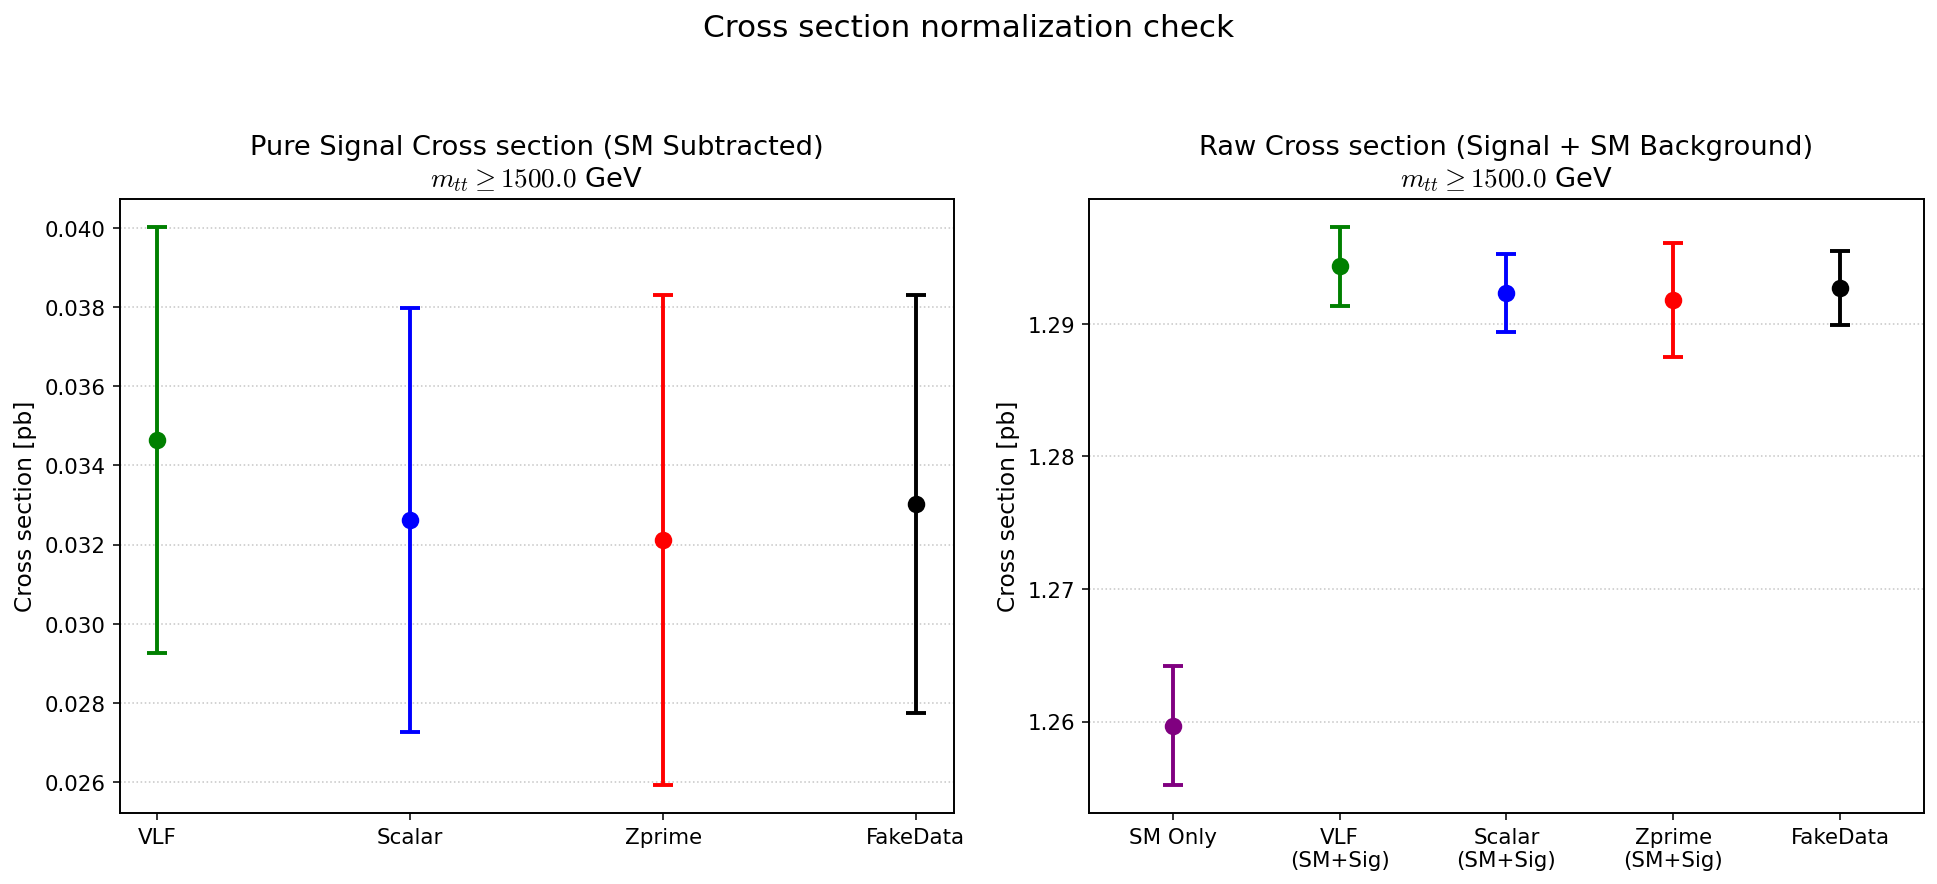

In [5]:
# ------------------------------------------------------------
# Histogram Generation (Applying Luminosity)
# ------------------------------------------------------------
lum = 500.0
bins = np.linspace(1500, 4500, 60 + 1)

# Generate SM Histogram
w_sm = df_sm['weight'].values
h_sm, _ = np.histogram(df_sm['m_tt'], bins=bins, weights=w_sm)
hErr_sm, _ = np.histogram(df_sm['m_tt'], bins=bins, weights=w_sm**2)

# Generate BSM Histograms in the exact order: [VLF, Scalar, Zprime, FakeData]
bsm_hists = []
bms_histsErr = []
for model in ['VLF', 'Scalar', 'Zprime', 'FakeData']:
    df_model = df_bsm[df_bsm['label'] == model]
    w_model = df_model['weight'].values
    h_model, _ = np.histogram(df_model['m_tt'], bins=bins, weights=w_model)
    hErr_model, _ = np.histogram(df_model['m_tt'], bins=bins, weights=w_model**2)
    bsm_hists.append(h_model)
    bms_histsErr.append(hErr_model)

# ------------------------------------------------------------
# Setup Variables for the Tests
# ------------------------------------------------------------
mTT_start = 1500.0
tail_mask = bins[:-1] >= mTT_start

print(f"Integrating tail from m_tt >= {mTT_start} GeV")
print("-" * 50)

# ------------------------------------------------------------------
# TEST 1: Total cross section for mtt > 1500.0 (Signal + Background)
# ------------------------------------------------------------------
tail_sum_SM  = np.sum(h_sm[tail_mask])
tail_sum_SM_Err = np.sqrt(np.sum(hErr_sm[tail_mask]))

tail_sum_NLO = np.sum(bsm_hists[0][tail_mask])
tail_sum_NLO_Err = np.sqrt(np.sum(bms_histsErr[0][tail_mask]))

tail_sum_S   = np.sum(bsm_hists[1][tail_mask])
tail_sum_S_Err = np.sqrt(np.sum(bms_histsErr[1][tail_mask]))

tail_sum_Zp  = np.sum(bsm_hists[2][tail_mask])
tail_sum_Zp_Err = np.sqrt(np.sum(bms_histsErr[2][tail_mask]))

tail_sum_Fake = np.sum(bsm_hists[3][tail_mask])
tail_sum_Fake_Err = np.sqrt(np.sum(bms_histsErr[3][tail_mask]))

yDM_S = np.sqrt(tail_sum_NLO / tail_sum_S)
mu_Zp = np.sqrt(tail_sum_NLO / tail_sum_Zp)

print("TEST 1: SM + Sginal")
print(f"SM:           {tail_sum_SM:.4f} +- {tail_sum_SM_Err:.4f}")
print(f"VLF NLO:      {tail_sum_NLO:.4f} +- {tail_sum_NLO_Err:.4f}")
print(f"Scalar NLO:   {tail_sum_S:.4f} +- {tail_sum_S_Err:.4f}")
print(f"Z prime:      {tail_sum_Zp:.4f} +- {tail_sum_Zp_Err:.4f}")
print(f"Fake Data:    {tail_sum_Fake:.4f} +- {tail_sum_Fake_Err:.4f}")
print(f"yDM_S:        {yDM_S:.5e}")
print(f"mu_Z:         {mu_Zp:.5e}\n")

# --------------------------------------------------------------
# TEST 2: Cross sections of signal only (Background Subtracted)
# --------------------------------------------------------------
tail_sum_NLO_sig = np.sum(bsm_hists[0][tail_mask]) - tail_sum_SM
tail_sum_S_sig   = np.sum(bsm_hists[1][tail_mask]) - tail_sum_SM
tail_sum_Zp_sig  = np.sum(bsm_hists[2][tail_mask]) - tail_sum_SM
tail_sum_Fake_sig = np.sum(bsm_hists[3][tail_mask]) - tail_sum_SM

# Recalculating ratios based strictly on the BSM signal
yDM_S_sig = np.sqrt(tail_sum_NLO_sig / tail_sum_S_sig)
mu_Zp_sig = np.sqrt(tail_sum_NLO_sig / tail_sum_Zp_sig)

print("TEST 2: PURE SIGNAL (Background Subtracted)")
print(f"VLF NLO:      {tail_sum_NLO_sig:.4f} +- {(np.sqrt(tail_sum_NLO_Err**2 + tail_sum_SM_Err**2)):.4f}")
print(f"Scalar NLO:   {tail_sum_S_sig:.4f} +- {(np.sqrt(tail_sum_S_Err**2 + tail_sum_SM_Err**2)):.4f}")
print(f"Z prime:      {tail_sum_Zp_sig:.4f} +- {(np.sqrt(tail_sum_Zp_Err**2 + tail_sum_SM_Err**2)):.4f}")
print(f"Fake Data:    {tail_sum_Fake_sig:.4f} +- {(np.sqrt(tail_sum_Fake_Err**2 + tail_sum_SM_Err**2)):.4f}")
print(f"yDM_S:        {yDM_S_sig:.5e}")
print(f"mu_Z:         {mu_Zp_sig:.5e}")

# ------------------------------------------------------------
# Plotting the results
# ------------------------------------------------------------
labels_sub = ['VLF', 'Scalar', 'Zprime', 'FakeData']
yields_sub = [tail_sum_NLO_sig, tail_sum_S_sig, tail_sum_Zp_sig, tail_sum_Fake_sig]
errors_sub = [
    np.sqrt(tail_sum_NLO_Err**2 + tail_sum_SM_Err**2),
    np.sqrt(tail_sum_S_Err**2 + tail_sum_SM_Err**2),
    np.sqrt(tail_sum_Zp_Err**2 + tail_sum_SM_Err**2),
    np.sqrt(tail_sum_Fake_Err**2 + tail_sum_SM_Err**2)
]
colors_sub = ['green', 'blue', 'red', 'black']

labels_raw = ['SM Only', 'VLF\n(SM+Sig)', 'Scalar\n(SM+Sig)', 'Zprime\n(SM+Sig)', 'FakeData']
yields_raw = [tail_sum_SM, tail_sum_NLO, tail_sum_S, tail_sum_Zp, tail_sum_Fake]
errors_raw = [tail_sum_SM_Err, tail_sum_NLO_Err, tail_sum_S_Err, tail_sum_Zp_Err, tail_sum_Fake_Err]
colors_raw = ['purple', 'green', 'blue', 'red', 'black']

# Create the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- PLOT 1: Background Subtracted ---
# ax1.axhline(0, color='gray', linestyle='--', alpha=0.7, label='SM Baseline (0)')
for i in range(len(labels_sub)):
    ax1.errorbar(labels_sub[i], yields_sub[i], yerr=errors_sub[i],
                 fmt='o', color=colors_sub[i], markersize=8, capsize=5, capthick=2, elinewidth=2, label=labels_sub[i])

ax1.set_title(f"Pure Signal Cross section (SM Subtracted)\n$m_{{tt}} \geq {mTT_start}$ GeV", fontsize=14)
ax1.set_ylabel("Cross section [pb]", fontsize=12)
ax1.grid(True, axis='y', linestyle=':', alpha=0.7)
# ax1.legend(loc='best')

# --- PLOT 2: SM + Signal ---
for i in range(len(labels_raw)):
    ax2.errorbar(labels_raw[i], yields_raw[i], yerr=errors_raw[i],
                 fmt='o', color=colors_raw[i], markersize=8, capsize=5, capthick=2, elinewidth=2)

ax2.set_title(f"Raw Cross section (Signal + SM Background)\n$m_{{tt}} \geq {mTT_start}$ GeV", fontsize=14)
ax2.set_ylabel("Cross section [pb]", fontsize=12)
ax2.set_xlim(-0.5, 4.5)
ax2.grid(True, axis='y', linestyle=':', alpha=0.7)
ax2.legend(loc='best')

# Formatting
plt.suptitle("Cross section normalization check", fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('Integrated_Tail_Cross section.pdf', bbox_inches='tight')
plt.show()

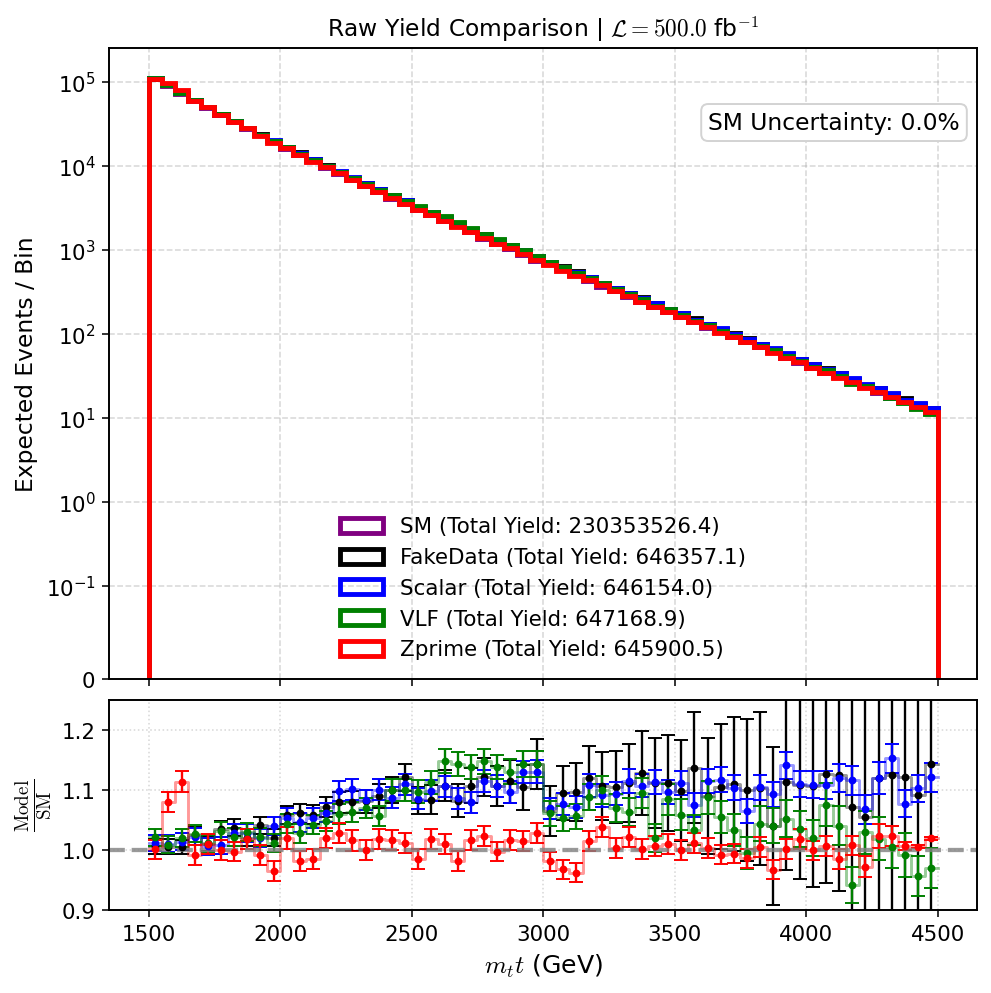

In [14]:
def plot_raw_weighted_histograms(df_bsm, df_sm, var, lum=500.0, bins=60, rng=None, density=False, sys_err=0.0):
    """
    Plots superimposed 1D distributions (Main) and their ratio to SM (Sub-panel) with Error Bars.
    Distributions are plotted with their raw expected yields for the given luminosity.
    """
    label_col = "label" if "label" in df_bsm.columns else "model"
    weight_col_bsm = "weight"
    weight_col_sm = "weight"

    target_bsm_models = ["FakeData", "Scalar", "VLF", "Zprime"]

    # --- Color Mapping ---
    color_map = {
        'SM': 'purple',
        'VLF': 'green',
        'Scalar': 'blue',
        'Zprime': 'red',
        'FakeData': 'black'
    }

    # Clean the DataFrames
    df_b_clean = df_bsm[[label_col, var, weight_col_bsm]].replace([np.inf, -np.inf], np.nan).dropna()
    df_s_clean = df_sm[[var, weight_col_sm]].replace([np.inf, -np.inf], np.nan).dropna()

    if rng is not None:
        bin_edges = np.linspace(rng[0], rng[1], bins + 1)
    else:
        g_min = min(df_b_clean[var].min(), df_s_clean[var].min())
        g_max = max(df_b_clean[var].max(), df_s_clean[var].max())
        bin_edges = np.linspace(g_min, g_max, bins + 1)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    hist_data = {}

    # Extract and Bin SM
    x_sm = df_s_clean[var].values
    w_sm = df_s_clean[weight_col_sm].values * lum * 1000.0

    h_sm, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm, density=density)
    hErr_sm_stat_sq, _ = np.histogram(x_sm, bins=bin_edges, weights=w_sm**2)

    # APPLY SM SYSTEMATIC ERROR
    hErr_sm = np.sqrt(hErr_sm_stat_sq + (sys_err * h_sm)**2)

    hist_data['SM'] = {'h': h_sm, 'err': hErr_sm, 'lbl': f"SM (Total Yield: {np.sum(w_sm):.1f})"}

    # Extract and Bin BSM Models
    for lab, sub in df_b_clean.groupby(label_col):
        lab_str = lab.decode('utf-8') if isinstance(lab, bytes) else str(lab)
        if lab_str not in target_bsm_models:
            continue

        x = sub[var].values
        w = sub[weight_col_bsm].values * lum * 1000.0

        h, _ = np.histogram(x, bins=bin_edges, weights=w, density=density)

        # Determine specific error type based on Model vs Data
        if lab_str == 'FakeData':
            # Poisson statistical uncertainty for "Data"
            err = np.sqrt(np.abs(h))
        else:
            # MC Sum of Squared Weights for BSM Models
            hErr_stat_sq, _ = np.histogram(x, bins=bin_edges, weights=w**2)
            err = np.sqrt(hErr_stat_sq)

        hist_data[lab_str] = {'h': h, 'err': err, 'lbl': f"{lab_str} (Total Yield: {np.sum(h):.1f})"}

    # ------------------------------------------------------------
    # Setup Figure (Main Panel + Ratio Panel)
    # ------------------------------------------------------------
    fig, (ax_main, ax_ratio) = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                                            gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

    # Plot lines and their ratios
    for lab_str, data in hist_data.items():

        c = color_map.get(lab_str, 'gray')

        # Plot the main step histogram
        ax_main.hist(bin_centers, bins=bin_edges, weights=np.abs(data['h']),
                     histtype="step", linewidth=2.5, label=data['lbl'], color=c)

        # Compute and plot the ratio to SM with Error Bars
        if lab_str != 'SM':
            with np.errstate(divide='ignore', invalid='ignore'):
                # Calculate Ratio
                ratio = np.where(h_sm > 0, data['h'] / h_sm, np.nan)

                # Propagate Error: delta_R = (1/SM) * sqrt( err_BSM^2 + (Ratio * err_SM)^2 )
                ratio_err = np.where(
                    h_sm > 0,
                    (1.0 / h_sm) * np.sqrt(data['err']**2 + (ratio**2 * hErr_sm**2)),
                    np.nan
                )

            # Plot error bars at bin centers
            ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, color=c,
                              fmt='o', ms=3, capsize=3.5, elinewidth=1.2)


            ratio_padded = np.append(ratio, ratio[-1])
            ax_ratio.step(bin_edges, ratio_padded, where='post', linewidth=1.5, color=c, alpha=0.4)

    # ------------------------------------------------------------
    # Formatting
    # ------------------------------------------------------------
    # Main Axes
    ax_main.set_title(rf"Raw Yield Comparison | $\mathcal{{L}} = {lum}$ fb$^{{-1}}$", fontsize=12)
    ax_main.set_ylabel("Density" if density else "Expected Events / Bin", fontsize=12)
    ax_main.legend(loc="best", framealpha=1.0)
    # Place the SM Uncertainty Box safely using .format()
    sm_text = r"SM Uncertainty: {:.1f}%".format(sys_err * 100)
    ax_main.text(0.98, 0.90, sm_text,
        transform=ax_main.transAxes,
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='lightgray', alpha=1.0))

    ax_main.set_yscale('symlog', linthresh=1e-1)
    ax_main.grid(True, linestyle='--', alpha=0.5)

    # Ratio Axes
    ax_ratio.axhline(1.0, color='gray', linestyle='--', alpha=0.8)
    ax_ratio.set_xlabel(rf'${var}$ (GeV)' if var == 'm_tt' else var, fontsize=13)
    ax_ratio.set_ylabel(r"$\frac{\mathrm{Model}}{\mathrm{SM}}$", fontsize=14)
    ax_ratio.grid(True, linestyle=':', alpha=0.5)
    ax_ratio.set_ylim(0.9, 1.25)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Execution
# ------------------------------------------------------------
observables = [
    ("m_tt", (300, 5000)),
]

LUMI = 500.0

for v, rng in observables:
    plot_raw_weighted_histograms(
        df_bsm=df_bsm,
        df_sm=df_sm,
        var=v,
        lum=LUMI,
        bins=60,
        rng=(1500,4500),
        density=False,
        sys_err=0.00
    )

In [12]:
# ------------------------------------------------------------
# m_cut Scan Configuration
# ------------------------------------------------------------
labels = ["FakeData", "Scalar", "VLF", "Zprime"]
mcuts = [ 1500, 1800, 2000, 2200, 2500]
mcut_max = 4_500
bin_width = 100.0
L_target = 500.0 # fb^{-1}
eps_values = [0.0, 0.02, 0.05, 0.10]

# ------------------------------------------------------------
# Luminosity Scan Configuration (Notebook)
# ------------------------------------------------------------
lumi_targets = [300., 500., 1000., 1500., 2000., 2500., 3000.]

# ------------------------------------------------------------
# Data Extraction
# ------------------------------------------------------------
var = "m_tt"  # Variable of the distributions

# Clean the DataFrames
df_sm_clean = df_sm[[var, "weight"]].replace([np.inf, -np.inf], np.nan).dropna()
df_sm_clean = df_sm_clean[df_sm_clean[var] > 0]

df_hyp_clean = df_bsm[["label", var, "weight"]].replace([np.inf, -np.inf], np.nan).dropna()
df_hyp_clean = df_hyp_clean[df_hyp_clean[var] > 0]

# Extract into pure NumPy dictionaries
sm_data = {
    "x": df_sm_clean[var].values,
    "w": df_sm_clean["weight"].values
}

bsm_data = {}
for lab, sub in df_hyp_clean.groupby("label"):
    lab_str = lab.decode('utf-8') if isinstance(lab, bytes) else str(lab)
    if lab_str in labels:
        bsm_data[lab_str] = {
            "x": sub[var].values,
            "w": sub["weight"].values
        }

# ------------------------------------------------------------
# Load the m cut and luminosity scan data frames
# ------------------------------------------------------------
df_mcut = hp.run_fast_mcut_scan(sm_data, bsm_data, labels, mcuts=mcuts,
                                mcut_max=mcut_max, bin_width=bin_width,
                                L_target=L_target, eps_values=eps_values,
                                fake_model='FakeData', sig_norm = False)

# Run the scan once to calculate both Shape and Falloff metrics but for luminosity
df_lumi = hp.run_fast_lumi_scan(sm_data, bsm_data, labels, target_mcut=1500, mcut_max=4500,
                                bin_width=100.0, lumi_targets=lumi_targets, eps_values=eps_values,
                                fake_model='FakeData', sig_norm = False)


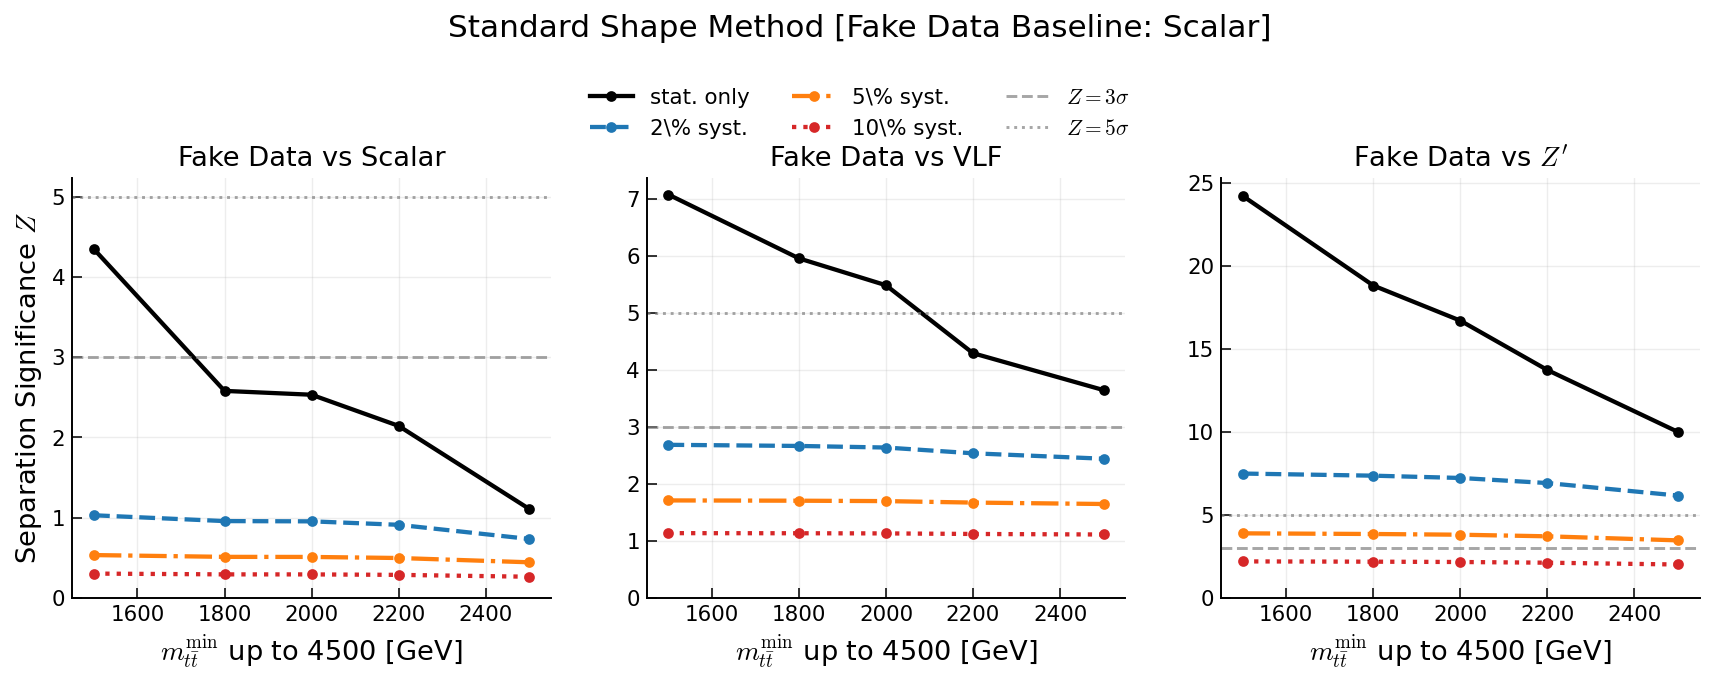

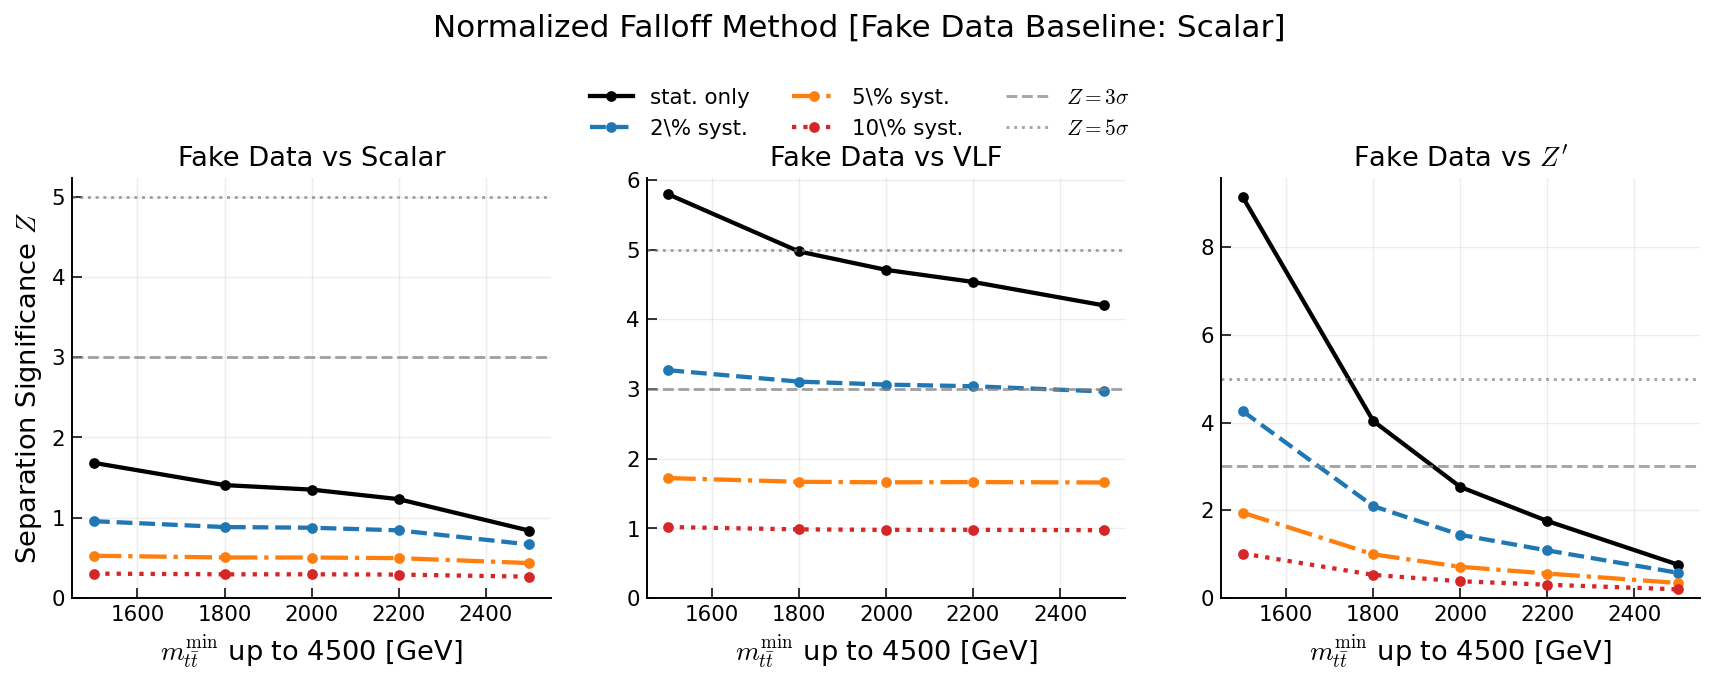

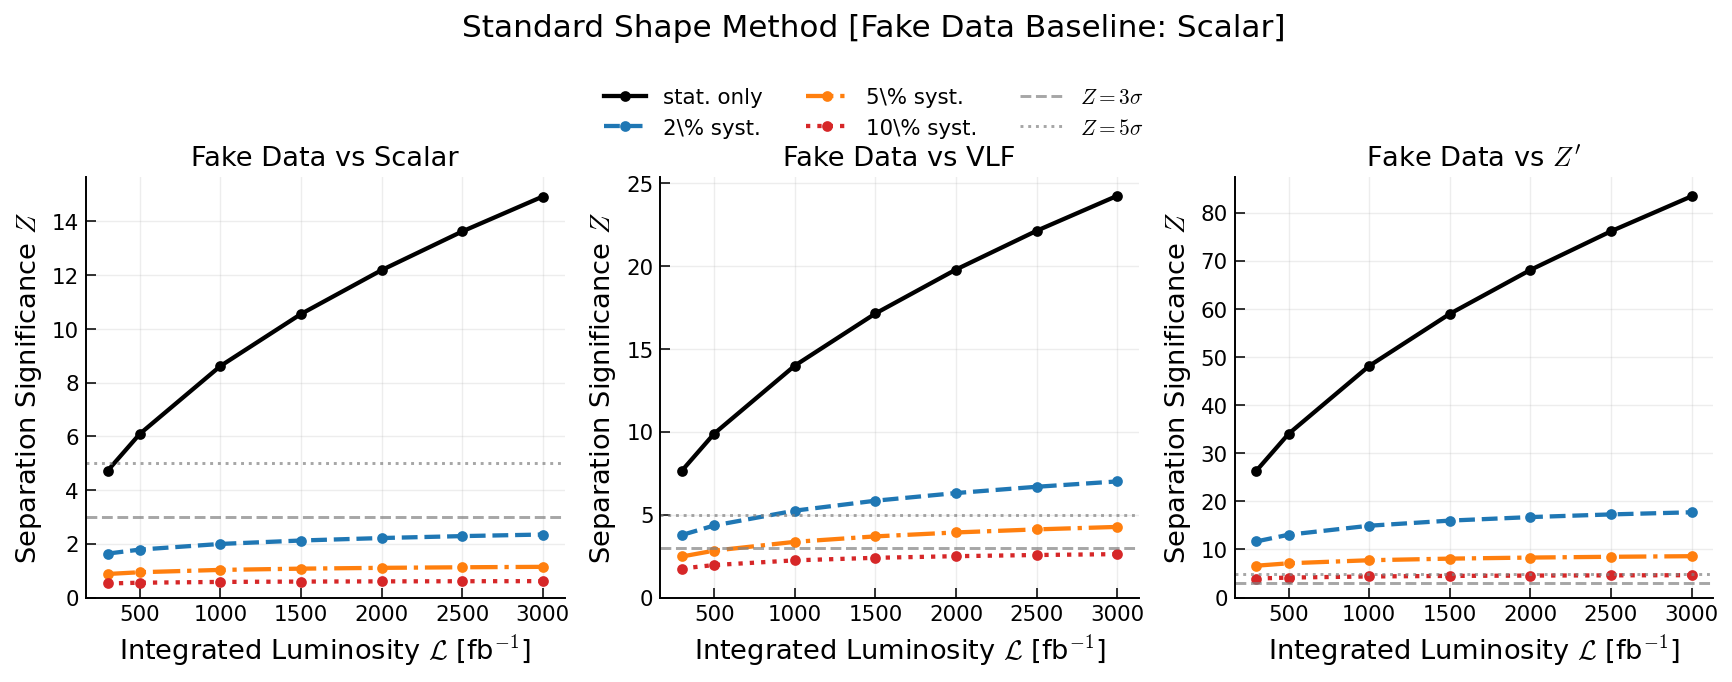

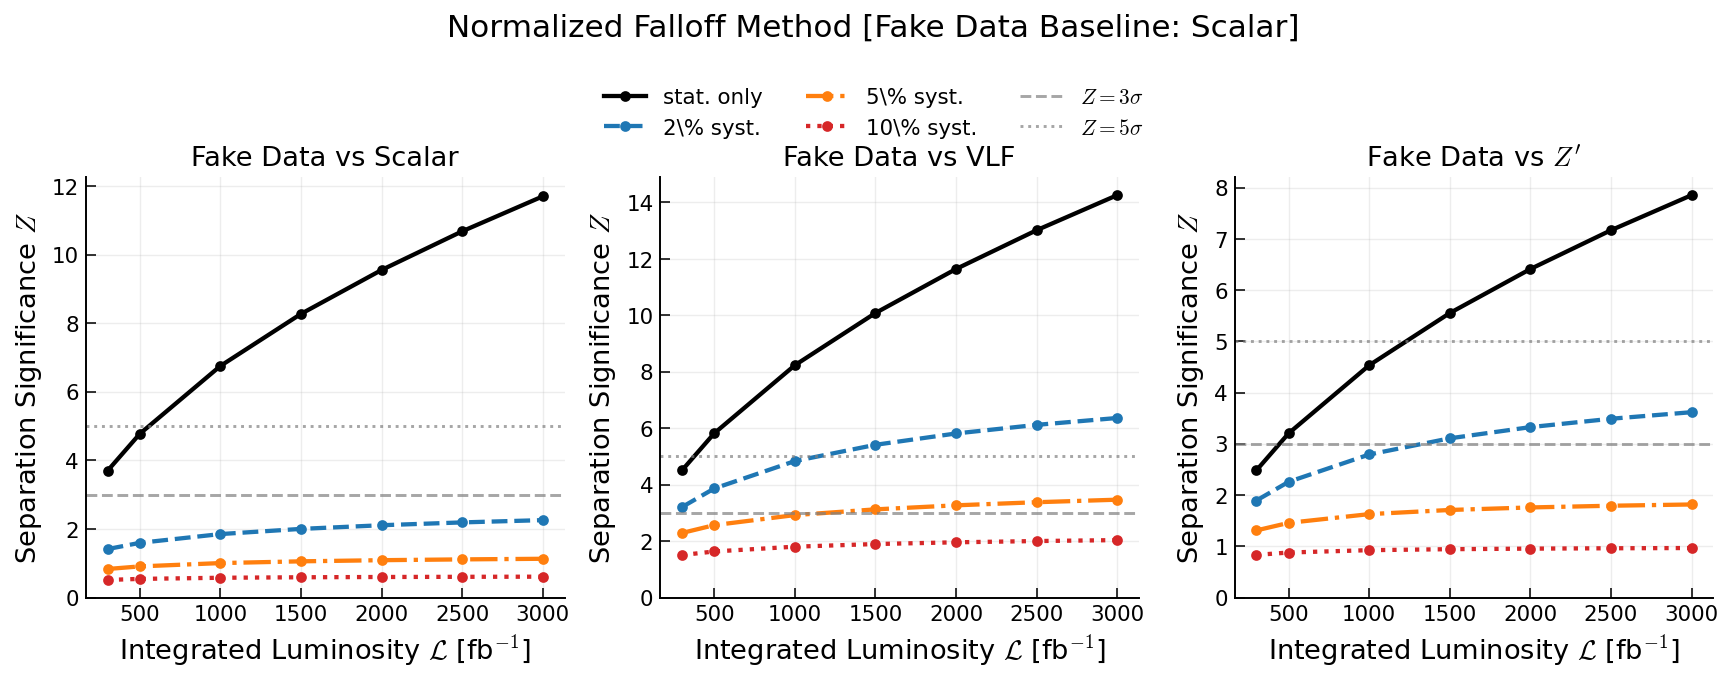

In [15]:
# Create output directory
outdir = Path("paper_plots_systematics")
outdir.mkdir(parents=True, exist_ok=True)

#  Plot Mass Cut Scans
hp.plot_mcut_syst_grid(df_mcut, mcut_max, eps_values, metric="sh",
                       outfile=outdir / "syst_grid_mcut_shape.pdf",
                       fake_model='Scalar')

hp.plot_mcut_syst_grid(df_mcut, mcut_max, eps_values, metric="fa",
                       outfile=outdir / "syst_grid_mcut_falloff.pdf",
                       fake_model='Scalar')

# Plot Luminosity Scans
hp.plot_lumi_syst_grid(df_lumi, eps_values, metric="sh",
                       outfile=outdir / "syst_grid_lumi_shape.pdf",
                       shareY = False, fake_model='Scalar')

hp.plot_lumi_syst_grid(df_lumi, eps_values, metric="fa",
                       outfile=outdir / "syst_grid_lumi_falloff.pdf",
                       shareY= False, fake_model='Scalar')


#hp.plot_ratio_pairwise(df_mcut, mcut_max, eps_values,
 #                      outfile=outdir / "improvement_ratio_mcut.pdf")

#hp.plot_ratio_pairwise_lumi(df_lumi, target_mcut=1500, eps_values=eps_values,
 #                           outfile=outdir / "improvement_ratio_lumi.pdf")


## OBS:
### The Fake Data vs Scalar significance now being low enougth is due Monte Carlo fluctuations. Since we are generating SM + signal, the SM content also fluctuates. When i generated the SM + signal separated, the SM content in all models are the same. Therefore, Monte Carlo fluctuations on the SM affects the shape and fallof results.